# Wheat Plant Disease Classification using EfficientNet-B3

This notebook presents a complete, reproducible deep learning pipeline for
classifying wheat plant diseases using a pretrained **EfficientNet-B3**
architecture in PyTorch.

### Key Highlights
- Uses a clean **train / validation / test** split provided by the dataset
- Handles **inconsistent folder naming** across splits with explicit label mapping
- Fine-tunes an ImageNet-pretrained EfficientNet-B3 model
- Incorporates **early stopping** and **learning rate scheduling**
- Evaluates performance on a held-out **test set**
- Includes **Grad-CAM visualizations** for model interpretability
- Provides a simple **inference code** for reuse in projects (no retraining required)



## 1. Imports and Configuration

In [17]:
import os
import random
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
from PIL import Image

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [18]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)


## 2. Dataset

In [19]:
from pathlib import Path

DATA_DIR = Path("./data")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "valid"
TEST_DIR  = DATA_DIR / "test"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32
EPOCHS = 15
LR = 3e-4
IMG_SIZE = 300
PATIENCE = 3


In [20]:
assert TRAIN_DIR.exists()
assert VAL_DIR.exists()
assert TEST_DIR.exists()

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [22]:
CANONICAL_CLASSES = [
    "aphid",
    "black rust",
    "blast",
    "brown rust",
    "common root rot",
    "fusarium head blight",
    "healthy",
    "leaf blight",
    "mildew",
    "mite",
    "septoria",
    "smut",
    "stem fly",
    "tan spot",
    "yellow rust"
]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CANONICAL_CLASSES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(CANONICAL_CLASSES)


In [23]:
def normalize_folder(folder):
    name = folder.lower()
    for suf in ["_test_valid", "_valid", "_test"]:
        if name.endswith(suf):
            name = name.replace(suf, "")
    name = name.replace("_", " ").strip()
    return name


In [24]:
class MappedImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        folders = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )

        classes = folders
        class_to_idx = {}

        for folder in folders:
            canonical = normalize_folder(folder)
            if canonical not in CLASS_TO_IDX:
                raise ValueError(
                    f"Unknown class '{canonical}' from folder '{folder}'"
                )
            class_to_idx[folder] = CLASS_TO_IDX[canonical]

        return classes, class_to_idx


In [25]:
train_ds = MappedImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = MappedImageFolder(VAL_DIR, transform=val_test_transform)
test_ds  = MappedImageFolder(TEST_DIR, transform=val_test_transform)


### 2.2 Dataloader

In [26]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)


In [27]:
assert set(train_ds.class_to_idx.values()) == \
       set(val_ds.class_to_idx.values()) == \
       set(test_ds.class_to_idx.values())
# print(train_ds[0][1], val_ds[0][1], test_ds[0][1])


## 3. Model Architecture (EfficientNet-B3)

In [28]:
model = models.efficientnet_b3(
    weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model.to(DEVICE)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Total parameters: 10,719,287


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)


## 4. Training

In [15]:
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    train_correct, train_total = 0, 0

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_correct += (out.argmax(1) == y).sum().item()
        train_total += y.size(0)

    train_acc = train_correct / train_total

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break


Epoch 1/15 | Train Acc: 0.7373 | Val Acc: 0.8067
Epoch 2/15 | Train Acc: 0.8695 | Val Acc: 0.8667
Epoch 3/15 | Train Acc: 0.9058 | Val Acc: 0.8967
Epoch 4/15 | Train Acc: 0.9240 | Val Acc: 0.9067
Epoch 5/15 | Train Acc: 0.9366 | Val Acc: 0.9100
Epoch 6/15 | Train Acc: 0.9478 | Val Acc: 0.9133
Epoch 7/15 | Train Acc: 0.9554 | Val Acc: 0.9300
Epoch 8/15 | Train Acc: 0.9600 | Val Acc: 0.9200
Epoch 9/15 | Train Acc: 0.9660 | Val Acc: 0.9233
Epoch 10/15 | Train Acc: 0.9672 | Val Acc: 0.9300
Early stopping triggered.


## 5. Model Evaluation

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

In [17]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=[c.title() for c in CANONICAL_CLASSES]
))


                      precision    recall  f1-score   support

               Aphid       0.98      1.00      0.99        50
          Black Rust       0.98      0.90      0.94        50
               Blast       0.96      1.00      0.98        50
          Brown Rust       0.91      1.00      0.95        50
     Common Root Rot       1.00      0.98      0.99        50
Fusarium Head Blight       1.00      0.98      0.99        50
             Healthy       1.00      0.08      0.15        50
         Leaf Blight       0.94      0.96      0.95        50
              Mildew       1.00      0.98      0.99        50
                Mite       1.00      0.96      0.98        50
            Septoria       1.00      1.00      1.00        50
                Smut       1.00      1.00      1.00        50
            Stem Fly       0.98      1.00      0.99        50
            Tan Spot       0.92      0.96      0.94        50
         Yellow Rust       0.54      1.00      0.70        50

      

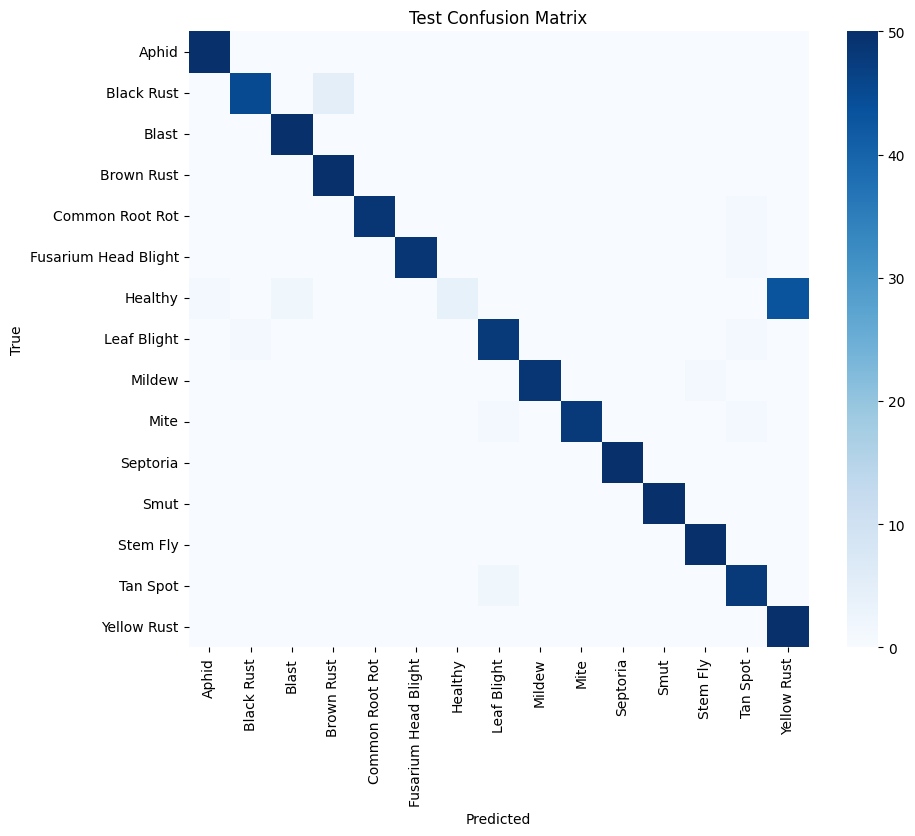

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=[c.title() for c in CANONICAL_CLASSES],
    yticklabels=[c.title() for c in CANONICAL_CLASSES],
    cmap="Blues",
    annot=False
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()


## 6. GradCAM Visualization 

In [19]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        # Global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.squeeze().cpu().numpy()

def overlay_cam(img_path, cam, alpha=0.5):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (w, h))

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlay



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


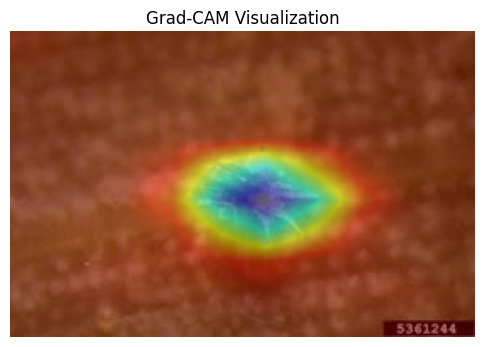

In [20]:
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)
img_path = "/kaggle/input/wheat-plant-diseases/data/test/mite_test/mite_28.png"

model.eval()

img = Image.open(img_path).convert("RGB")
input_tensor = val_test_transform(img).unsqueeze(0).to(DEVICE)

cam = gradcam.generate(input_tensor)

overlay = overlay_cam(img_path, cam)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()


## 7. Inference

In [30]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

def predict_image(img_path):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    img = val_test_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(img)
        idx = out.argmax(1).item()

    return CANONICAL_CLASSES[idx].title()

In [33]:
# Example
# predict_image(str(TEST_DIR / "mite/mite_29.png"))
predict_image(str(TEST_DIR / "smut_test/smut_test_2.png"))

'Smut'